# 01_PCA_KMeans — Task 1 + Task 2

**Mục tiêu:** dùng PCA để giảm số chiều dữ liệu, sau đó dùng K-Means để phân nhóm khách hàng và so sánh kết quả khi có/không có PCA.

Notebook làm theo hướng nhập môn, sử dụng các thư viện cơ bản: `pandas`, `matplotlib` và `scikit-learn`.

**Lưu ý trước khi chạy:** đặt file `01_PCA_KMeans.ipynb` cùng thư mục với `eda_completed_master_dataset.csv`. Dữ liệu có nhiều dòng giao dịch cho mỗi khách hàng, vì vậy notebook sẽ tổng hợp dữ liệu về **mỗi khách hàng một dòng** trước khi phân cụm. Sau đó, nhãn cụm sẽ được gắn ngược trở lại dữ liệu giao dịch gốc.

## 1. Import thư viện và đọc dữ liệu

Các thư viện cần dùng:
- `pandas` để đọc và xử lý dữ liệu.
- `StandardScaler` để đưa các biến số về cùng thang đo trước khi chạy PCA/K-Means.
- `PCA` để giảm số chiều.
- `KMeans` và `silhouette_score` để phân cụm và đánh giá sơ bộ.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# File CSV cần nằm cùng thư mục với notebook
df = pd.read_csv("eda_completed_master_dataset.csv")

print("Kích thước dữ liệu gốc:", df.shape)
display(df.head())

Kích thước dữ liệu gốc: (1000, 19)


,OrderID,CustomerID,CustomerName,Age,Gender,City,ProductID,Quantity,TotalAmount,PurchaseDate,PaymentMethod,ProductName,Brand,Category,Price,Rating,Source,Currency,Price_VND_ref
0,ORD00001,C0214,Nguyễn Quốc Khoa,37,Nam,Hải Phòng,P10412,3,57000,2026-01-01,Ví điện tử,Bàn chải đánh răng trẻ em từ 2 đến 6 tuổi P/S ...,P/S,Bàn chải đánh răng,19000.0,4.88,Pharmacity_VN,VND,19000.0
1,ORD00002,C0020,Trần Hữu Thành,18,Nam,Đà Nẵng,P18082,3,123000,2026-01-01,Thẻ ngân hàng,Kem Đánh Răng P/S Chăm Sóc Toàn Diện (tuýp 230g),P/S,Kem đánh răng,41000.0,4.92,Pharmacity_VN,VND,41000.0
2,ORD00003,C0144,Bùi Thị Xuân,32,Nữ,TP. Hồ Chí Minh,P29620,1,194250,2026-01-01,Tiền mặt,Kem Đánh Răng Marvis Jasmin Mint Vị Hoa Nhài &...,Marvis,Kem đánh răng,194250.0,4.87,Pharmacity_VN,VND,194250.0
3,ORD00004,C0253,Nguyễn Minh Huy,51,Nam,Hà Nội,P28349,1,110000,2026-01-02,COD,Nước súc miệng SMC Ag+ vệ sinh răng miệng (Cha...,Unknown,Nước súc miệng,110000.0,4.85,Pharmacity_VN,VND,110000.0
4,ORD00005,C0138,Nguyễn Mỹ Dương,27,Nữ,Cần Thơ,P25083,3,37500,2026-01-02,Tiền mặt,Băng vệ sinh ban ngày siêu mỏng cánh Kotex Gar...,Kotex,Băng vệ sinh,12500.0,4.96,Pharmacity_VN,VND,12500.0


## 2. Kiểm tra dữ liệu và chuẩn bị dữ liệu khách hàng

Dữ liệu gốc là dữ liệu theo giao dịch. Nếu phân cụm trực tiếp từng giao dịch, cùng một khách hàng có thể xuất hiện ở nhiều cụm. Vì mục tiêu là **Customer Segmentation**, ta tổng hợp theo `CustomerID` để mỗi khách hàng chỉ còn một dòng.

Các đặc trưng số được chọn:
- `Age`: tuổi trung bình của khách hàng trong dữ liệu.
- `Order_Count`: số giao dịch.
- `Total_Spending`: tổng số tiền đã chi.
- `Avg_Order_Value`: giá trị giao dịch trung bình.
- `Avg_Quantity`: số lượng sản phẩm trung bình mỗi giao dịch.
- `Avg_Rating`: điểm đánh giá trung bình.

Không đưa ID, tên và các cột dạng chữ vào K-Means vì các cột đó không phải là đặc trưng số phù hợp để tính khoảng cách.

In [2]:
print("Số giá trị thiếu theo cột (dữ liệu gốc):")
print(df.isnull().sum())

customer_features = df.groupby("CustomerID").agg(
    Age=("Age", "mean"),
    Order_Count=("OrderID", "count"),
    Total_Spending=("TotalAmount", "sum"),
    Avg_Order_Value=("TotalAmount", "mean"),
    Avg_Quantity=("Quantity", "mean"),
    Avg_Rating=("Rating", "mean")
).reset_index()

feature_columns = [
    "Age", "Order_Count", "Total_Spending",
    "Avg_Order_Value", "Avg_Quantity", "Avg_Rating"
]

print("Số khách hàng:", customer_features["CustomerID"].nunique())
print("Kích thước bảng đặc trưng khách hàng:", customer_features.shape)
display(customer_features.head())

Số giá trị thiếu theo cột (dữ liệu gốc):
OrderID          0
CustomerID       0
CustomerName     0
Age              0
Gender           0
City             0
ProductID        0
Quantity         0
TotalAmount      0
PurchaseDate     0
PaymentMethod    0
ProductName      0
Brand            0
Category         0
Price            0
Rating           0
Source           0
Currency         0
Price_VND_ref    0
dtype: int64
Số khách hàng: 350
Kích thước bảng đặc trưng khách hàng: (350, 7)


,CustomerID,Age,Order_Count,Total_Spending,Avg_Order_Value,Avg_Quantity,Avg_Rating
0,C0001,35.0,2,80000,40000.0,1.5,4.69
1,C0002,29.0,1,143650,143650.0,1.0,4.74
2,C0003,36.0,2,504000,252000.0,2.0,4.78
3,C0004,45.0,1,192500,192500.0,1.0,4.65
4,C0005,28.0,1,232000,232000.0,2.0,4.87


## Task 1 — PCA (Dimensionality Reduction)

### 3. Chuẩn hóa dữ liệu

Các biến như tổng chi tiêu có thang đo lớn hơn nhiều so với điểm đánh giá. Nếu không chuẩn hóa, các biến có giá trị lớn có thể ảnh hưởng mạnh hơn đến PCA và K-Means. Ta dùng `StandardScaler()` để chuẩn hóa các đặc trưng số.

In [3]:
X = customer_features[feature_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Số khách hàng:", X_scaled.shape[0])
print("Số đặc trưng ban đầu:", X_scaled.shape[1])

Số khách hàng: 350
Số đặc trưng ban đầu: 6


### 4. Chọn số thành phần PCA bằng Explained Variance

PCA tạo ra các thành phần mới. Ta xem **Cumulative Explained Variance Ratio** (tỷ lệ phương sai tích lũy) và chọn số thành phần nhỏ nhất đạt ít nhất 85%. Sau đó kiểm tra tỷ lệ đạt được có nằm trong khoảng 85%–95% mà đề yêu cầu hay không.

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.3696,0.3696
1,PC2,0.1905,0.5601
2,PC3,0.1721,0.7322
3,PC4,0.1531,0.8853
4,PC5,0.1056,0.9909
5,PC6,0.0091,1.0000


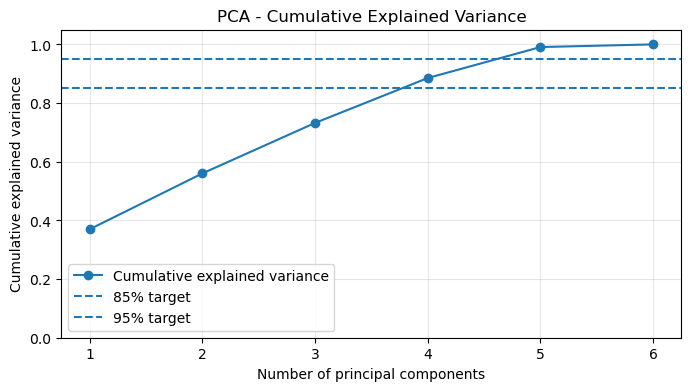

Số thành phần PCA được chọn: 4
Phương sai tích lũy được giữ lại: 88.53%
Kết quả nằm trong khoảng 85%–95% theo yêu cầu đề bài.


In [4]:
pca_all = PCA()
pca_all.fit(X_scaled)

explained_variance = pca_all.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

variance_table = pd.DataFrame({
    "Principal Component": [f"PC{i}" for i in range(1, len(explained_variance) + 1)],
    "Explained Variance Ratio": explained_variance,
    "Cumulative Explained Variance": cumulative_variance
})
display(variance_table.round(4))

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
         marker="o", label="Cumulative explained variance")
plt.axhline(y=0.85, linestyle="--", label="85% target")
plt.axhline(y=0.95, linestyle="--", label="95% target")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA - Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Chọn số thành phần ít nhất để đạt từ 85% phương sai tích lũy trở lên
n_components = int(np.argmax(cumulative_variance >= 0.85) + 1)
retained_variance = cumulative_variance[n_components - 1]

print("Số thành phần PCA được chọn:", n_components)
print(f"Phương sai tích lũy được giữ lại: {retained_variance:.2%}")

if 0.85 <= retained_variance <= 0.95:
    print("Kết quả nằm trong khoảng 85%–95% theo yêu cầu đề bài.")
else:
    print("Lưu ý: tỷ lệ phương sai chưa nằm trong khoảng 85%–95%; cần xem lại biểu đồ và số thành phần.")

In [5]:
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print("Kích thước dữ liệu sau PCA:", X_pca.shape)
print("Số chiều trước PCA:", X_scaled.shape[1])
print("Số chiều sau PCA:", X_pca.shape[1])

Kích thước dữ liệu sau PCA: (350, 4)
Số chiều trước PCA: 6
Số chiều sau PCA: 4


### 5. Vẽ dữ liệu sau PCA trên mặt phẳng PC1–PC2

Biểu đồ dùng hai thành phần đầu tiên để xem dữ liệu được chiếu sang không gian mới như thế nào. Đây là hình minh họa 2D; nếu mô hình giữ nhiều hơn hai thành phần thì K-Means ở phần sau vẫn dùng **tất cả thành phần đã chọn**, không chỉ PC1 và PC2.

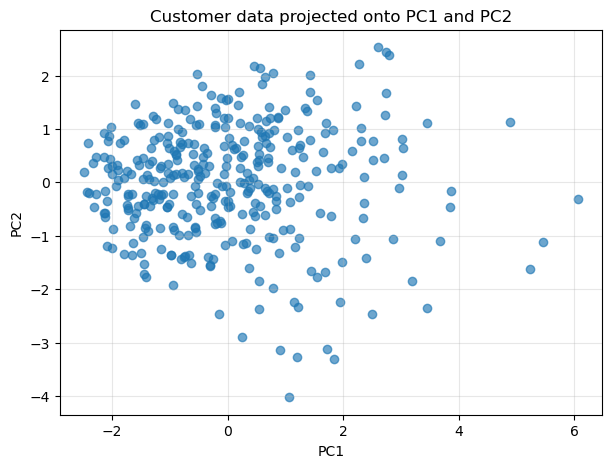

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.65)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer data projected onto PC1 and PC2")
plt.grid(True, alpha=0.3)
plt.show()

## Task 2 — Customer Segmentation bằng K-Means

### 6. Tìm số cụm K bằng Elbow Method và Silhouette Score

Ta thử các giá trị `K` từ 2 đến 10:
- **WCSS / Inertia**: tổng bình phương khoảng cách trong cụm; thường giảm khi tăng K. Elbow Method tìm điểm mà mức giảm bắt đầu chậm lại.
- **Silhouette Score**: càng cao thường cho thấy các cụm tách biệt tốt hơn. Điểm này chỉ là một chỉ số tham khảo, không khẳng định cụm là “đúng tuyệt đối”.

Phần này tính cả dữ liệu chuẩn hóa ban đầu và dữ liệu sau PCA để có thể so sánh.

In [7]:
k_values = range(2, 11)
results_original = []
results_pca = []

for k in k_values:
    # K-Means trên các đặc trưng gốc đã chuẩn hóa
    model_original = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_original = model_original.fit_predict(X_scaled)
    results_original.append({
        "K": k,
        "WCSS": model_original.inertia_,
        "Silhouette Score": silhouette_score(X_scaled, labels_original)
    })

    # K-Means trên dữ liệu đã giảm chiều bằng PCA
    model_pca = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_pca = model_pca.fit_predict(X_pca)
    results_pca.append({
        "K": k,
        "WCSS": model_pca.inertia_,
        "Silhouette Score": silhouette_score(X_pca, labels_pca)
    })

results_original = pd.DataFrame(results_original)
results_pca = pd.DataFrame(results_pca)

print("Kết quả trên đặc trưng gốc đã chuẩn hóa:")
display(results_original.round(4))
print("Kết quả trên dữ liệu sau PCA:")
display(results_pca.round(4))

d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

Kết quả trên đặc trưng gốc đã chuẩn hóa:


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,K,WCSS,Silhouette Score
0,2,1605.4708,0.2207
1,3,1402.6668,0.1785
2,4,1231.4044,0.1756
3,5,1113.2267,0.1796
4,6,1007.3387,0.1848
5,7,933.4561,0.1798
6,8,876.9365,0.1708
7,9,829.8737,0.1811
8,10,786.5189,0.1716


Kết quả trên dữ liệu sau PCA:


,K,WCSS,Silhouette Score
0,2,1364.7723,0.2435
1,3,1167.3316,0.2283
2,4,993.4107,0.2090
3,5,887.0636,0.2023
4,6,793.2018,0.2060
5,7,722.2962,0.2100
6,8,669.0582,0.2114
7,9,622.4450,0.2044
8,10,589.9281,0.2016


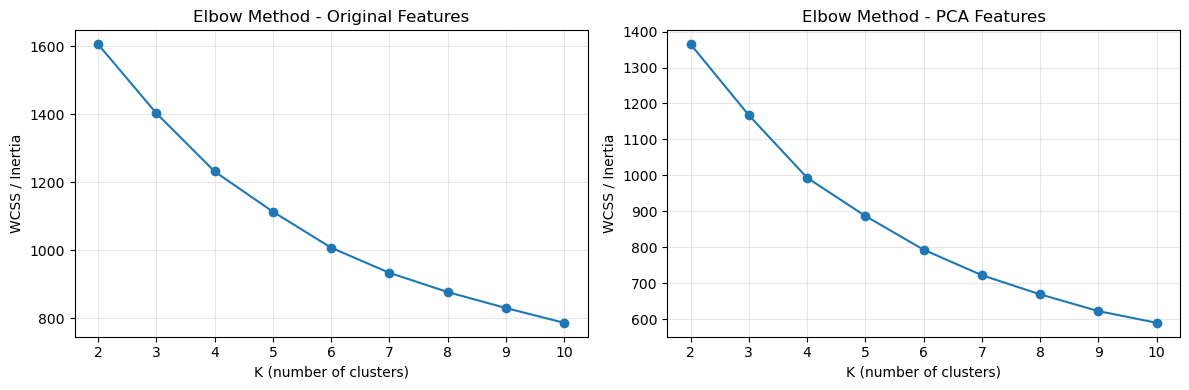

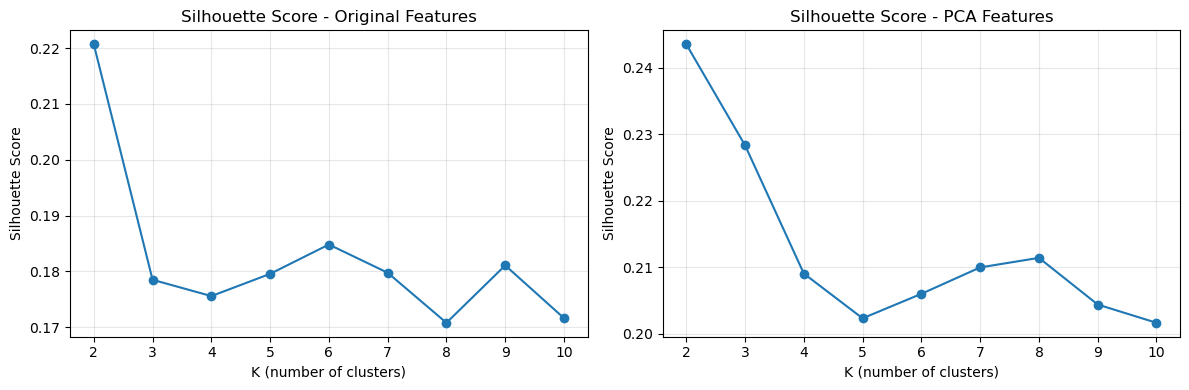

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(results_original["K"], results_original["WCSS"], marker="o")
axes[0].set_title("Elbow Method - Original Features")
axes[0].set_xlabel("K (number of clusters)")
axes[0].set_ylabel("WCSS / Inertia")
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_pca["K"], results_pca["WCSS"], marker="o")
axes[1].set_title("Elbow Method - PCA Features")
axes[1].set_xlabel("K (number of clusters)")
axes[1].set_ylabel("WCSS / Inertia")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(results_original["K"], results_original["Silhouette Score"], marker="o")
axes[0].set_title("Silhouette Score - Original Features")
axes[0].set_xlabel("K (number of clusters)")
axes[0].set_ylabel("Silhouette Score")
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_pca["K"], results_pca["Silhouette Score"], marker="o")
axes[1].set_title("Silhouette Score - PCA Features")
axes[1].set_xlabel("K (number of clusters)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7. Chọn K và so sánh hai cách phân cụm

Ta chọn K có Silhouette Score cao nhất trong khoảng đã thử. Khi đọc biểu đồ Elbow, hãy xem đường WCSS giảm nhanh ở đoạn nào rồi chậm lại; với dữ liệu này điểm elbow có thể không quá rõ, nên dùng thêm Silhouette Score để hỗ trợ lựa chọn.

Nhãn cụm (`0`, `1`, ...) chỉ là tên do mô hình tạo ra, không phải thứ hạng tốt/xấu của khách hàng.

In [9]:
best_k_original = int(results_original.loc[results_original["Silhouette Score"].idxmax(), "K"])
best_k_pca = int(results_pca.loc[results_pca["Silhouette Score"].idxmax(), "K"])

print("K có Silhouette Score cao nhất - Original:", best_k_original)
print("K có Silhouette Score cao nhất - PCA:", best_k_pca)

# Fit mô hình cuối cùng cho từng loại dữ liệu
kmeans_original = KMeans(n_clusters=best_k_original, random_state=42, n_init=10)
cluster_original = kmeans_original.fit_predict(X_scaled)

kmeans_pca = KMeans(n_clusters=best_k_pca, random_state=42, n_init=10)
cluster_pca = kmeans_pca.fit_predict(X_pca)

comparison = pd.DataFrame({
    "Method": ["Original scaled features", "PCA-reduced features"],
    "Number of clusters (K)": [best_k_original, best_k_pca],
    "WCSS / Inertia": [kmeans_original.inertia_, kmeans_pca.inertia_],
    "Silhouette Score": [
        silhouette_score(X_scaled, cluster_original),
        silhouette_score(X_pca, cluster_pca)
    ]
})
print("So sánh mô hình cuối cùng:")
display(comparison.round(4))

K có Silhouette Score cao nhất - Original: 2
K có Silhouette Score cao nhất - PCA: 2
So sánh mô hình cuối cùng:


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Method,Number of clusters (K),WCSS / Inertia,Silhouette Score
0,Original scaled features,2,1605.4708,0.2207
1,PCA-reduced features,2,1364.7723,0.2435


### 8. Vẽ cụm và xem số khách hàng trong từng cụm

Để nhìn rõ hơn, ta vẽ cả hai bộ nhãn trên cùng mặt phẳng PC1–PC2. Ở biểu đồ bên trái, nhãn được tạo từ các đặc trưng gốc đã chuẩn hóa nhưng hiển thị ở tọa độ PCA; bên phải, nhãn được tạo trực tiếp từ dữ liệu PCA.

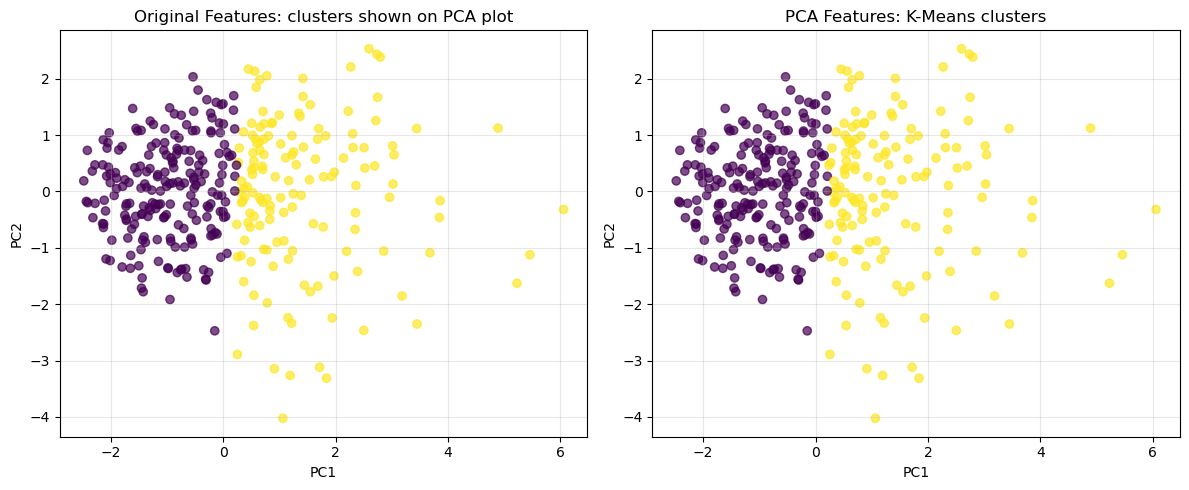

Số khách hàng trong từng cụm (nhãn của hai mô hình được tạo riêng):


,Original features,PCA features
Cluster label,,
0,208,207
1,142,143


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_original, cmap="viridis", alpha=0.7)
axes[0].set_title("Original Features: clusters shown on PCA plot")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True, alpha=0.3)

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_pca, cmap="viridis", alpha=0.7)
axes[1].set_title("PCA Features: K-Means clusters")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

cluster_sizes = pd.DataFrame({
    "Original features": pd.Series(cluster_original).value_counts().sort_index(),
    "PCA features": pd.Series(cluster_pca).value_counts().sort_index()
}).fillna(0).astype(int)
cluster_sizes.index.name = "Cluster label"
print("Số khách hàng trong từng cụm (nhãn của hai mô hình được tạo riêng):")
display(cluster_sizes)

### 9. Gắn `Cluster_Label` trở lại dữ liệu gốc

Hai cột nhãn riêng được giữ lại để tiện đối chiếu:
- `Cluster_Label_Original`: nhãn từ K-Means trên các đặc trưng ban đầu đã chuẩn hóa.
- `Cluster_Label_PCA`: nhãn từ K-Means trên dữ liệu sau PCA.

Theo kết quả so sánh, notebook dùng nhãn từ mô hình PCA làm `Cluster_Label` chính. Nhãn được nối vào dữ liệu gốc theo `CustomerID`, vì vậy tất cả giao dịch của cùng một khách hàng sẽ có cùng nhãn cụm.

In [15]:
import os
import joblib
customer_clusters = customer_features[["CustomerID"]].copy()
customer_clusters["Cluster_Label_Original"] = cluster_original
customer_clusters["Cluster_Label_PCA"] = cluster_pca
customer_clusters["Cluster_Label"] = cluster_pca

df_with_clusters = df.merge(customer_clusters, on="CustomerID", how="left")

print("Dữ liệu gốc sau khi gắn nhãn cụm:", df_with_clusters.shape)
print("Số dòng chưa được gán Cluster_Label:", df_with_clusters["Cluster_Label"].isna().sum())
display(df_with_clusters[["CustomerID", "OrderID", "TotalAmount", "Cluster_Label_Original", "Cluster_Label_PCA", "Cluster_Label"]].head(10))

print("Số khách hàng theo Cluster_Label chính (PCA):")
display(customer_clusters["Cluster_Label"].value_counts().sort_index().rename("Number of customers").to_frame())

df_with_clusters.to_csv("data/eda_dataset_with_cluster_labels.csv", index=False, encoding="utf-8-sig")
print("Đã lưu: eda_dataset_with_cluster_labels.csv")
# Lưu các mô hình PCA và K-Means vào folder model

joblib.dump(pca, "model/pca.pkl")
joblib.dump(scaler,'model/scaler.pkl')
joblib.dump(kmeans_pca, "model/kmeans_pca.pkl")
print("- pca.pkl")
print("- kmeans_pca.pkl")


Dữ liệu gốc sau khi gắn nhãn cụm: (1000, 22)
Số dòng chưa được gán Cluster_Label: 0


,CustomerID,OrderID,TotalAmount,Cluster_Label_Original,Cluster_Label_PCA,Cluster_Label
0,C0214,ORD00001,57000,1,1,1
1,C0020,ORD00002,123000,0,0,0
2,C0144,ORD00003,194250,0,0,0
3,C0253,ORD00004,110000,0,0,0
4,C0138,ORD00005,37500,1,1,1
5,C0230,ORD00006,102000,1,1,1
6,C0057,ORD00007,540000,1,1,1
7,C0002,ORD00008,143650,0,0,0
8,C0193,ORD00009,75000,0,0,0
9,C0160,ORD00010,34000,0,0,0


Số khách hàng theo Cluster_Label chính (PCA):


,Number of customers
Cluster_Label,
0,207
1,143


Đã lưu: eda_dataset_with_cluster_labels.csv
- pca.pkl
- kmeans_pca.pkl


## 10. Nhận xét ngắn cho báo cáo

Sau khi chạy notebook, có thể viết phần nhận xét dựa trên các con số và biểu đồ vừa tạo:

1. **PCA:** số thành phần được giữ lại là số nhỏ nhất đạt tối thiểu 85% phương sai tích lũy. Báo cáo tỷ lệ phần trăm được in ra ở phần 4.
2. **Chọn K:** kết hợp biểu đồ WCSS (Elbow Method) với Silhouette Score. Nếu elbow không rõ, nêu rõ đã ưu tiên Silhouette Score trong khoảng K thử nghiệm.
3. **So sánh:** so sánh Silhouette Score của hai phương pháp trong bảng ở phần 7. Điểm cao hơn cho thấy độ tách biệt cụm tốt hơn theo chỉ số này, nhưng không chứng minh rằng nhóm khách hàng là hoàn hảo.


